# 12 — Full Strategy Comparison Backtest

## Purpose
This is the MASTER comparison notebook.
Every filter from notebooks 03–11 is evaluated here side-by-side.

## Methodology
- Same backtest engine for all scenarios (fair comparison)
- Same data period
- Same risk ($20 per trade)
- Same RR (2.0)
- Only the FILTERS change between scenarios

## Scenarios
1. **Baseline** — raw OB, no filters
2. **+ Session** — London + NY only
3. **+ Session + BOS** — structure break required
4. **+ Session + BOS + FVG** — imbalance required
5. **+ Session + BOS + FVG + Volume** — all confirmations
6. **+ Regime filter** — skip ranging markets
7. **FULL** — all filters active

## Decision rule
Keep a filter ONLY if it improves expectancy OR reduces max drawdown
WITHOUT reducing trade frequency below a usable level (< 1 trade/week).

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os

from strategy.ob_core import add_candle_features
from strategy.ob_signals import list_ob_signals_enhanced, OBSignalConfig, get_passed_signals

plt.style.use('dark_background')
plt.rcParams.update({'figure.figsize': (20, 8)})

SYMBOL    = 'XAUUSD'
RISK_USDT = 20.0
RR        = 2.0
START_BAL = 5_000    # matches notebook 08 INITIAL_CAPITAL
LEVERAGE  = 0        # 0 = no leverage; return% = PnL / START_BAL

# ── Date filter (set to None to use full history) ─────────────────────────
DATE_FROM = '2026-03-01'
DATE_TO   = '2026-05-20'
# ─────────────────────────────────────────────────────────────────────────

# ── Spread / fee config ───────────────────────────────────────────────────
# MT5 exports spread in points; for XAUUSD 1 point = 0.01 price unit.
# SPREAD_FALLBACK is used for bars where CSV spread = 0 (early data).
POINT_SIZE      = 0.01   # price units per MT5 point (XAUUSD)
SPREAD_FALLBACK = 25     # points (~0.20 price, ~2 pips) when CSV spread = 0
# ─────────────────────────────────────────────────────────────────────────

m5 = pd.read_csv(f'./data/{SYMBOL}/M5/ohlcv.csv', index_col=0, parse_dates=True)
h1 = pd.read_csv(f'./data/{SYMBOL}/H1/ohlcv.csv', index_col=0, parse_dates=True)

for df in [m5, h1]:
    df.index = pd.to_datetime(df.index, utc=True)
    if 'tick_volume' in df.columns and 'volume' not in df.columns:
        df.rename(columns={'tick_volume': 'volume'}, inplace=True)

m5, h1 = m5.sort_index(), h1.sort_index()

if DATE_FROM:
    m5 = m5[m5.index >= pd.Timestamp(DATE_FROM, tz='UTC')]
    h1 = h1[h1.index >= pd.Timestamp(DATE_FROM, tz='UTC')]
if DATE_TO:
    m5 = m5[m5.index <= pd.Timestamp(DATE_TO, tz='UTC')]
    h1 = h1[h1.index <= pd.Timestamp(DATE_TO, tz='UTC')]

m5 = add_candle_features(m5)

print(f'M5: {len(m5):,} bars | H1: {len(h1):,} bars')
print(f'Date range : {m5.index[0].date()} to {m5.index[-1].date()}')
print(f'Capital    : ${START_BAL:,}  |  Leverage: {LEVERAGE}  |  Risk/trade: ${RISK_USDT}')
print(f'Spread fallback: {SPREAD_FALLBACK} pts = {SPREAD_FALLBACK * POINT_SIZE:.2f} price units')


M5: 15,126 bars | H1: 1,261 bars
Date range : 2026-03-02 to 2026-05-18
Capital    : $5,000  |  Leverage: 0  |  Risk/trade: $20.0
Spread fallback: 25 pts = 0.25 price units


In [2]:
# ── Backtest engine ─────────────────────────────────────────────────────────
def backtest_signals(m5_df, signals_df, start_balance=10000.0, risk=20.0):
    """Fill-at-entry; evaluates TP/SL on subsequent bars; deducts spread cost.
    One position at a time — new signals are skipped while a position is open.
    """
    trades         = []
    balance        = start_balance
    equity         = [(m5_df.index[0], balance)]
    open_until_bar = -1   # bar index when current trade exits; -1 = no open position

    for _, sig in signals_df.iterrows():
        bar   = int(sig['signal_bar_index'])

        # Skip if a position is still open
        if bar <= open_until_bar:
            continue

        side  = sig['side']
        entry = float(sig['entry'])
        sl    = float(sig['sl'])
        tp    = float(sig['tp'])
        dist  = abs(entry - sl)
        qty   = risk / max(dist, 1e-9)

        # Spread cost: use actual bar spread when available, else fallback
        raw_spread  = m5_df.iloc[bar].get('spread', 0)
        spread_pts  = float(raw_spread) if raw_spread and raw_spread > 0 else SPREAD_FALLBACK
        spread_cost = spread_pts * POINT_SIZE * qty

        result = None
        exit_p = None
        exit_t = None

        for j in range(bar + 1, min(bar + 300, len(m5_df))):
            b = m5_df.iloc[j]
            hit_sl = b['low']  <= sl if side == 'buy' else b['high'] >= sl
            hit_tp = b['high'] >= tp if side == 'buy' else b['low']  <= tp
            if hit_sl and hit_tp:
                exit_p, result = sl, 'loss'
            elif hit_sl:
                exit_p, result = sl, 'loss'
            elif hit_tp:
                exit_p, result = tp, 'win'
            if result:
                exit_t         = m5_df.index[j]
                open_until_bar = j   # block new entries until after this bar
                break

        if result is None:
            continue

        gross_pnl = (exit_p - entry) * qty if side == 'buy' else (entry - exit_p) * qty
        pnl       = gross_pnl - spread_cost
        balance  += pnl
        equity.append((exit_t, balance))
        trades.append({
            'result'     : result,
            'pnl'        : pnl,
            'gross_pnl'  : gross_pnl,
            'spread_cost': spread_cost,
            'balance'    : balance,
            'side'       : side,
            'entry_time' : m5_df.index[bar],
        })

    return pd.DataFrame(trades), pd.Series({t: v for t, v in equity})


def calc_metrics(trades_df, start_balance=START_BAL):
    if trades_df.empty:
        return {k: None for k in ['trades','win_rate','expectancy','profit_factor','max_dd','return_pct','total_pnl','total_spread']}
    wins   = trades_df[trades_df['result']=='win']
    losses = trades_df[trades_df['result']=='loss']
    wr     = len(wins)/len(trades_df)
    aw     = wins['pnl'].mean()   if len(wins)   > 0 else 0
    al     = losses['pnl'].mean() if len(losses) > 0 else 0
    pf     = wins['pnl'].sum() / abs(losses['pnl'].sum()) \
             if len(losses) > 0 and losses['pnl'].sum() != 0 else 0
    dd     = 0.0
    peak   = start_balance
    for b in trades_df['balance']:
        peak = max(peak, b)
        dd   = max(dd, (peak - b) / peak * 100)
    total_pnl = trades_df['pnl'].sum()
    return {
        'trades'        : len(trades_df),
        'win_rate'      : round(wr*100, 1),
        'expectancy'    : round(wr*aw + (1-wr)*al, 2),
        'profit_factor' : round(pf, 2),
        'max_dd'        : round(dd, 1),
        'return_pct'    : round(total_pnl / start_balance * 100, 2),
        'total_pnl'     : round(total_pnl, 2),
        'total_spread'  : round(trades_df['spread_cost'].sum(), 2) if 'spread_cost' in trades_df.columns else None,
    }

print('Backtest engine ready (spread deducted | one position at a time).')

Backtest engine ready (spread deducted | one position at a time).


In [3]:
# ── Define filter scenarios ────────────────────────────────────────────────
scenarios = {
    '01_baseline': OBSignalConfig(rr=RR),
    '02_session' : OBSignalConfig(rr=RR, session_filter_enabled=True,
                                  allow_london=True, allow_new_york=True, allow_overlap=True),
    '03_+bos'    : OBSignalConfig(rr=RR, session_filter_enabled=True, require_bos=True),
    '04_+fvg'    : OBSignalConfig(rr=RR, session_filter_enabled=True,
                                  require_bos=True, require_fvg=True),
    '05_+volume' : OBSignalConfig(rr=RR, session_filter_enabled=True,
                                  require_bos=True, require_fvg=True,
                                  volume_filter_enabled=True),
    '06_+regime' : OBSignalConfig(rr=RR, session_filter_enabled=True,
                                  require_bos=True, require_fvg=True,
                                  volume_filter_enabled=True, regime_filter_enabled=True),
    '07_full'    : OBSignalConfig(rr=RR, session_filter_enabled=True,
                                  require_bos=True, require_fvg=True,
                                  volume_filter_enabled=True, regime_filter_enabled=True,
                                  liquidity_sweep_filter=False),  # sweep optional
}

# ── Run all scenarios ──────────────────────────────────────────────────────
all_metrics = {}
all_trades  = {}
all_equities= {}

for name, cfg in scenarios.items():
    sigs = list_ob_signals_enhanced(m5, h1=h1, risk_cash=RISK_USDT, config=cfg)
    sigs_pass = get_passed_signals(sigs)
    trades, equity = backtest_signals(m5, sigs_pass, start_balance=START_BAL, risk=RISK_USDT)
    all_trades[name]   = trades
    all_equities[name] = equity
    m = calc_metrics(trades)
    all_metrics[name]  = m
    print(f'{name:20s}: trades={m["trades"]} WR={m["win_rate"]}% exp={m["expectancy"]} PF={m["profit_factor"]} DD={m["max_dd"]}%')

print('\nAll scenarios complete.')

01_baseline         : trades=260 WR=49.2% exp=8.98 PF=1.86 DD=4.0%
02_session          : trades=184 WR=49.5% exp=9.12 PF=1.88 DD=2.9%
03_+bos             : trades=120 WR=49.2% exp=8.93 PF=1.86 DD=1.7%
04_+fvg             : trades=76 WR=52.6% exp=10.99 PF=2.13 DD=1.6%
05_+volume          : trades=13 WR=61.5% exp=16.44 PF=3.09 DD=0.4%
06_+regime          : trades=13 WR=61.5% exp=16.44 PF=3.09 DD=0.4%
07_full             : trades=13 WR=61.5% exp=16.44 PF=3.09 DD=0.4%

All scenarios complete.


In [4]:
# ── Metrics comparison table ────────────────────────────────────────────────
comparison = pd.DataFrame(all_metrics).T
comparison.index = [s.split('_', 1)[-1] for s in comparison.index]
print('\n=== STRATEGY COMPARISON ===')
print(comparison.to_string())

# Save results
os.makedirs('../notebooks_ob/results', exist_ok=True)
comparison.to_csv('../notebooks_ob/results/12_strategy_comparison.csv')
print('\nSaved to notebooks_ob/results/12_strategy_comparison.csv')


=== STRATEGY COMPARISON ===
          trades  win_rate  expectancy  profit_factor  max_dd  return_pct  total_pnl  total_spread
baseline   260.0      49.2        8.98           1.86     4.0       46.70    2335.14        144.86
session    184.0      49.5        9.12           1.88     2.9       33.56    1678.16        101.84
+bos       120.0      49.2        8.93           1.86     1.7       21.43    1071.53         68.47
+fvg        76.0      52.6       10.99           2.13     1.6       16.71     835.32         44.68
+volume     13.0      61.5       16.44           3.09     0.4        4.27     213.68          6.32
+regime     13.0      61.5       16.44           3.09     0.4        4.27     213.68          6.32
full        13.0      61.5       16.44           3.09     0.4        4.27     213.68          6.32

Saved to notebooks_ob/results/12_strategy_comparison.csv


fvg_only              : trades=176 WR=52.3% exp=10.79 PF=2.1 DD=2.6%
session+fvg           : trades=120 WR=55.0% exp=12.43 PF=2.34 DD=1.9%
session+fvg+volume    : trades=20 WR=60.0% exp=15.53 PF=2.89 DD=0.8%

=== FVG COMBINATION COMPARISON ===
                    trades  win_rate  expectancy  profit_factor  max_dd  return_pct  total_pnl  total_spread
fvg_only             176.0      52.3       10.79           2.10     2.6       37.97    1898.26        101.74
session+fvg          120.0      55.0       12.43           2.34     1.9       29.83    1491.53         68.47
session+fvg+volume    20.0      60.0       15.53           2.89     0.8        6.21     310.69          9.31


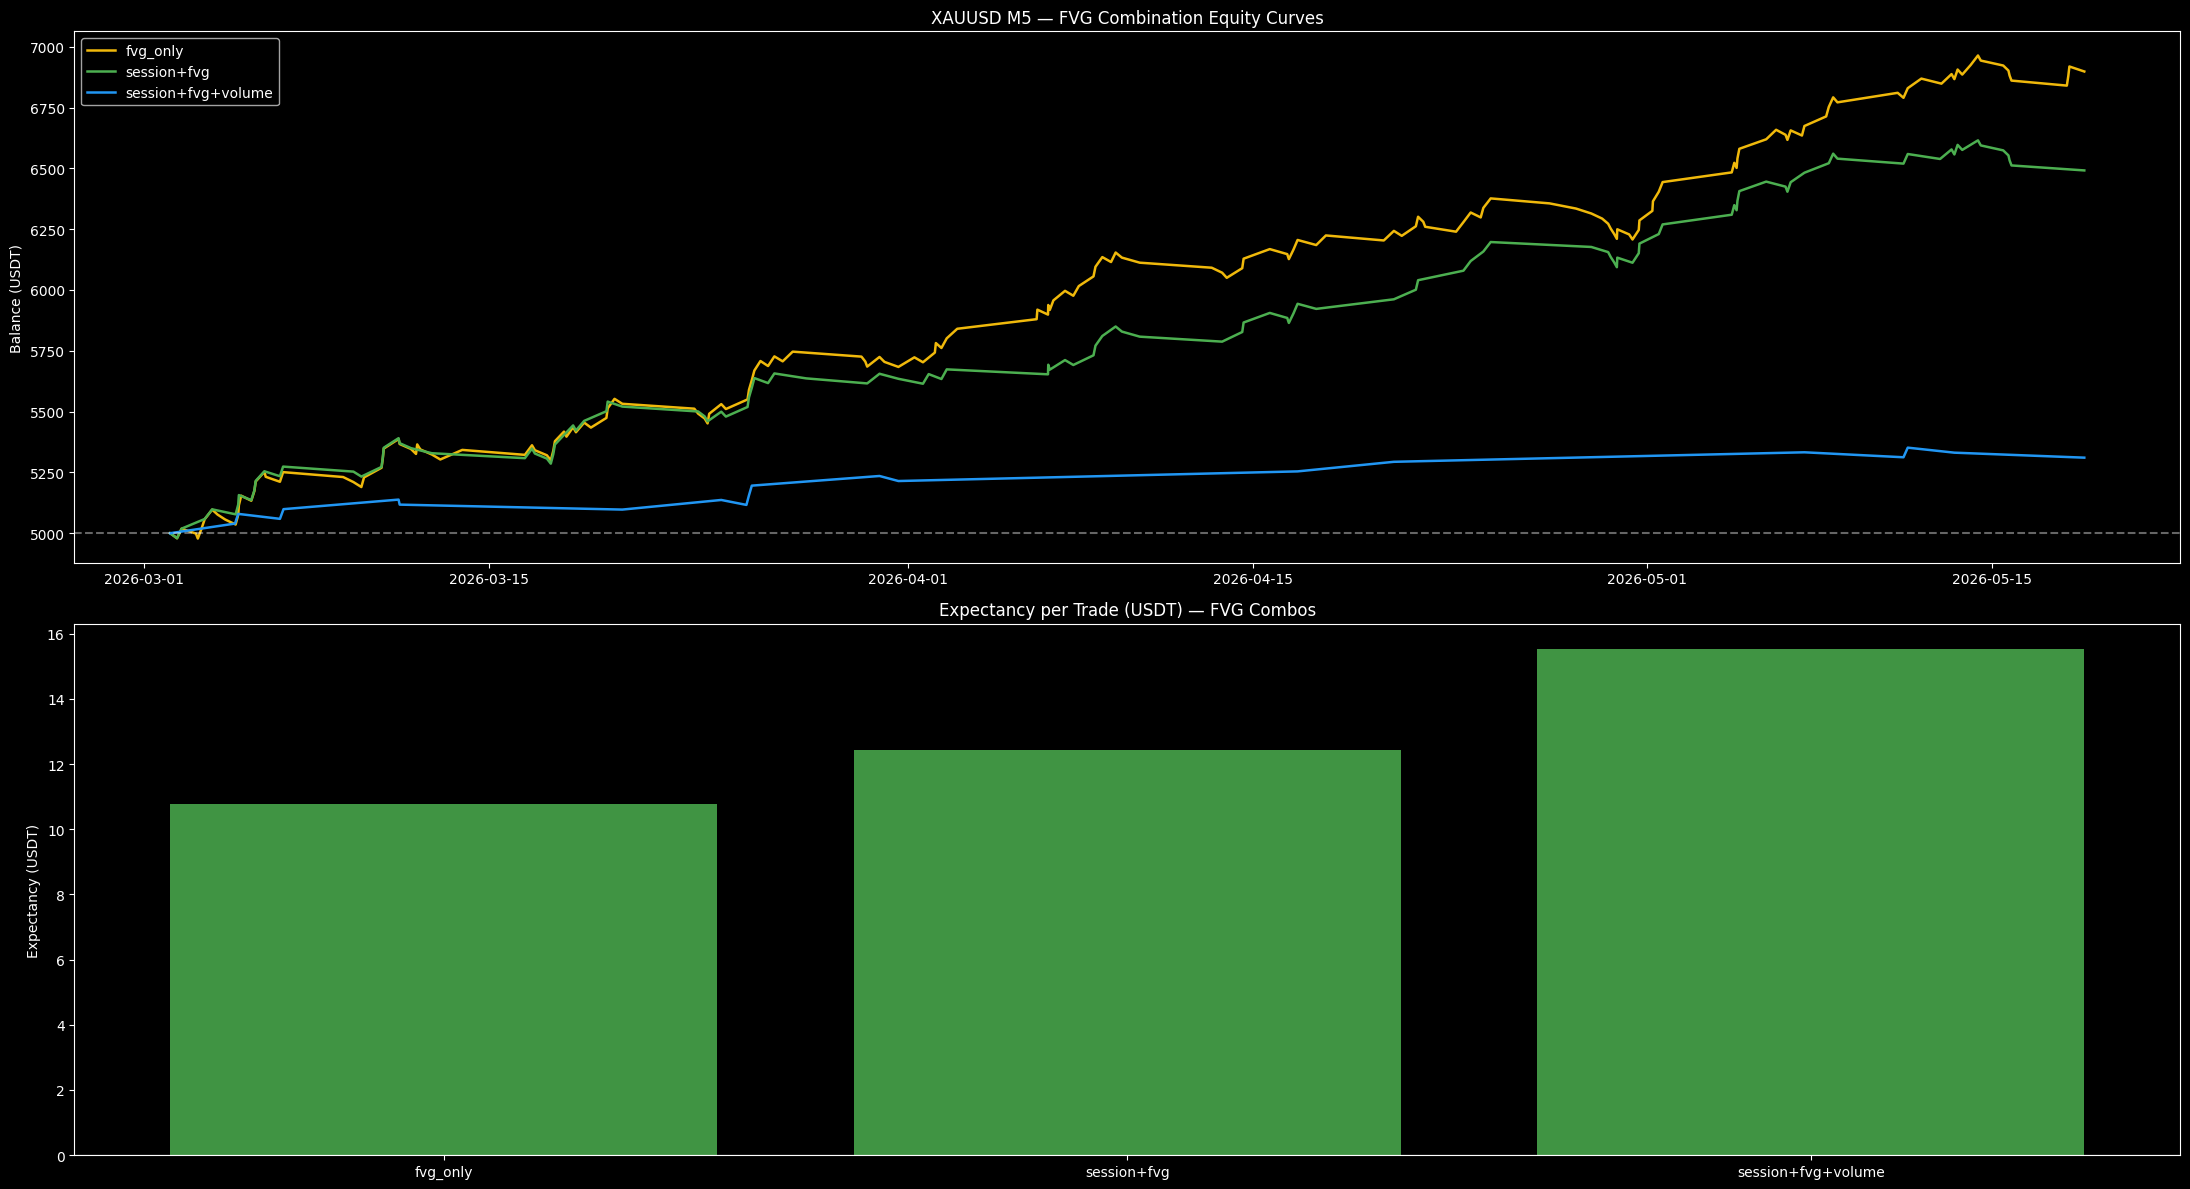

In [5]:
# ── Focused FVG combination comparison ───────────────────────────────────────────
# Isolates the contribution of BOS, Session, and Volume when paired with FVG:
#   A) fvg_only           — baseline + FVG (no session, no BOS)
#   B) session+fvg        — baseline + Session + FVG (no BOS)
#   C) session+fvg+volume — baseline + Session + FVG + Volume

fvg_scenarios = {
    'fvg_only'          : OBSignalConfig(rr=RR,
                                         require_fvg=True),
    'session+fvg'       : OBSignalConfig(rr=RR,
                                         session_filter_enabled=True,
                                         allow_london=True, allow_new_york=True, allow_overlap=True,
                                         require_fvg=True),
    'session+fvg+volume': OBSignalConfig(rr=RR,
                                         session_filter_enabled=True,
                                         allow_london=True, allow_new_york=True, allow_overlap=True,
                                         require_fvg=True,
                                         volume_filter_enabled=True),
}

fvg_metrics  = {}
fvg_trades   = {}
fvg_equities = {}

for name, cfg in fvg_scenarios.items():
    sigs = list_ob_signals_enhanced(m5, h1=h1, risk_cash=RISK_USDT, config=cfg)
    sigs_pass = get_passed_signals(sigs)
    trades, equity = backtest_signals(m5, sigs_pass, start_balance=START_BAL, risk=RISK_USDT)
    fvg_trades[name]   = trades
    fvg_equities[name] = equity
    m = calc_metrics(trades)
    fvg_metrics[name]  = m
    print(f'{name:22s}: trades={m["trades"]} WR={m["win_rate"]}% exp={m["expectancy"]} PF={m["profit_factor"]} DD={m["max_dd"]}%')

print('\n=== FVG COMBINATION COMPARISON ===')
fvg_comparison = pd.DataFrame(fvg_metrics).T
print(fvg_comparison.to_string())

# ── Equity curves ──────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(22, 12))

fvg_colors = ['#F0B90B', '#4CAF50', '#2196F3']
for (name, eq), color in zip(fvg_equities.items(), fvg_colors):
    if not eq.empty:
        axes[0].plot(eq.index, eq.values, label=name, color=color, linewidth=1.8)
axes[0].axhline(START_BAL, color='white', linestyle='--', alpha=0.4)
axes[0].set_title(f'{SYMBOL} M5 — FVG Combination Equity Curves')
axes[0].set_ylabel('Balance (USDT)')
axes[0].legend(loc='upper left')

expcts_fvg = [fvg_metrics[s]['expectancy'] or 0 for s in fvg_metrics]
bar_colors = ['#4CAF50' if e > 0 else '#F44336' for e in expcts_fvg]
axes[1].bar(list(fvg_metrics.keys()), expcts_fvg, color=bar_colors, alpha=0.85)
axes[1].axhline(0, color='white', linewidth=0.8)
axes[1].set_title('Expectancy per Trade (USDT) — FVG Combos')
axes[1].set_ylabel('Expectancy (USDT)')

plt.tight_layout()
plt.show()


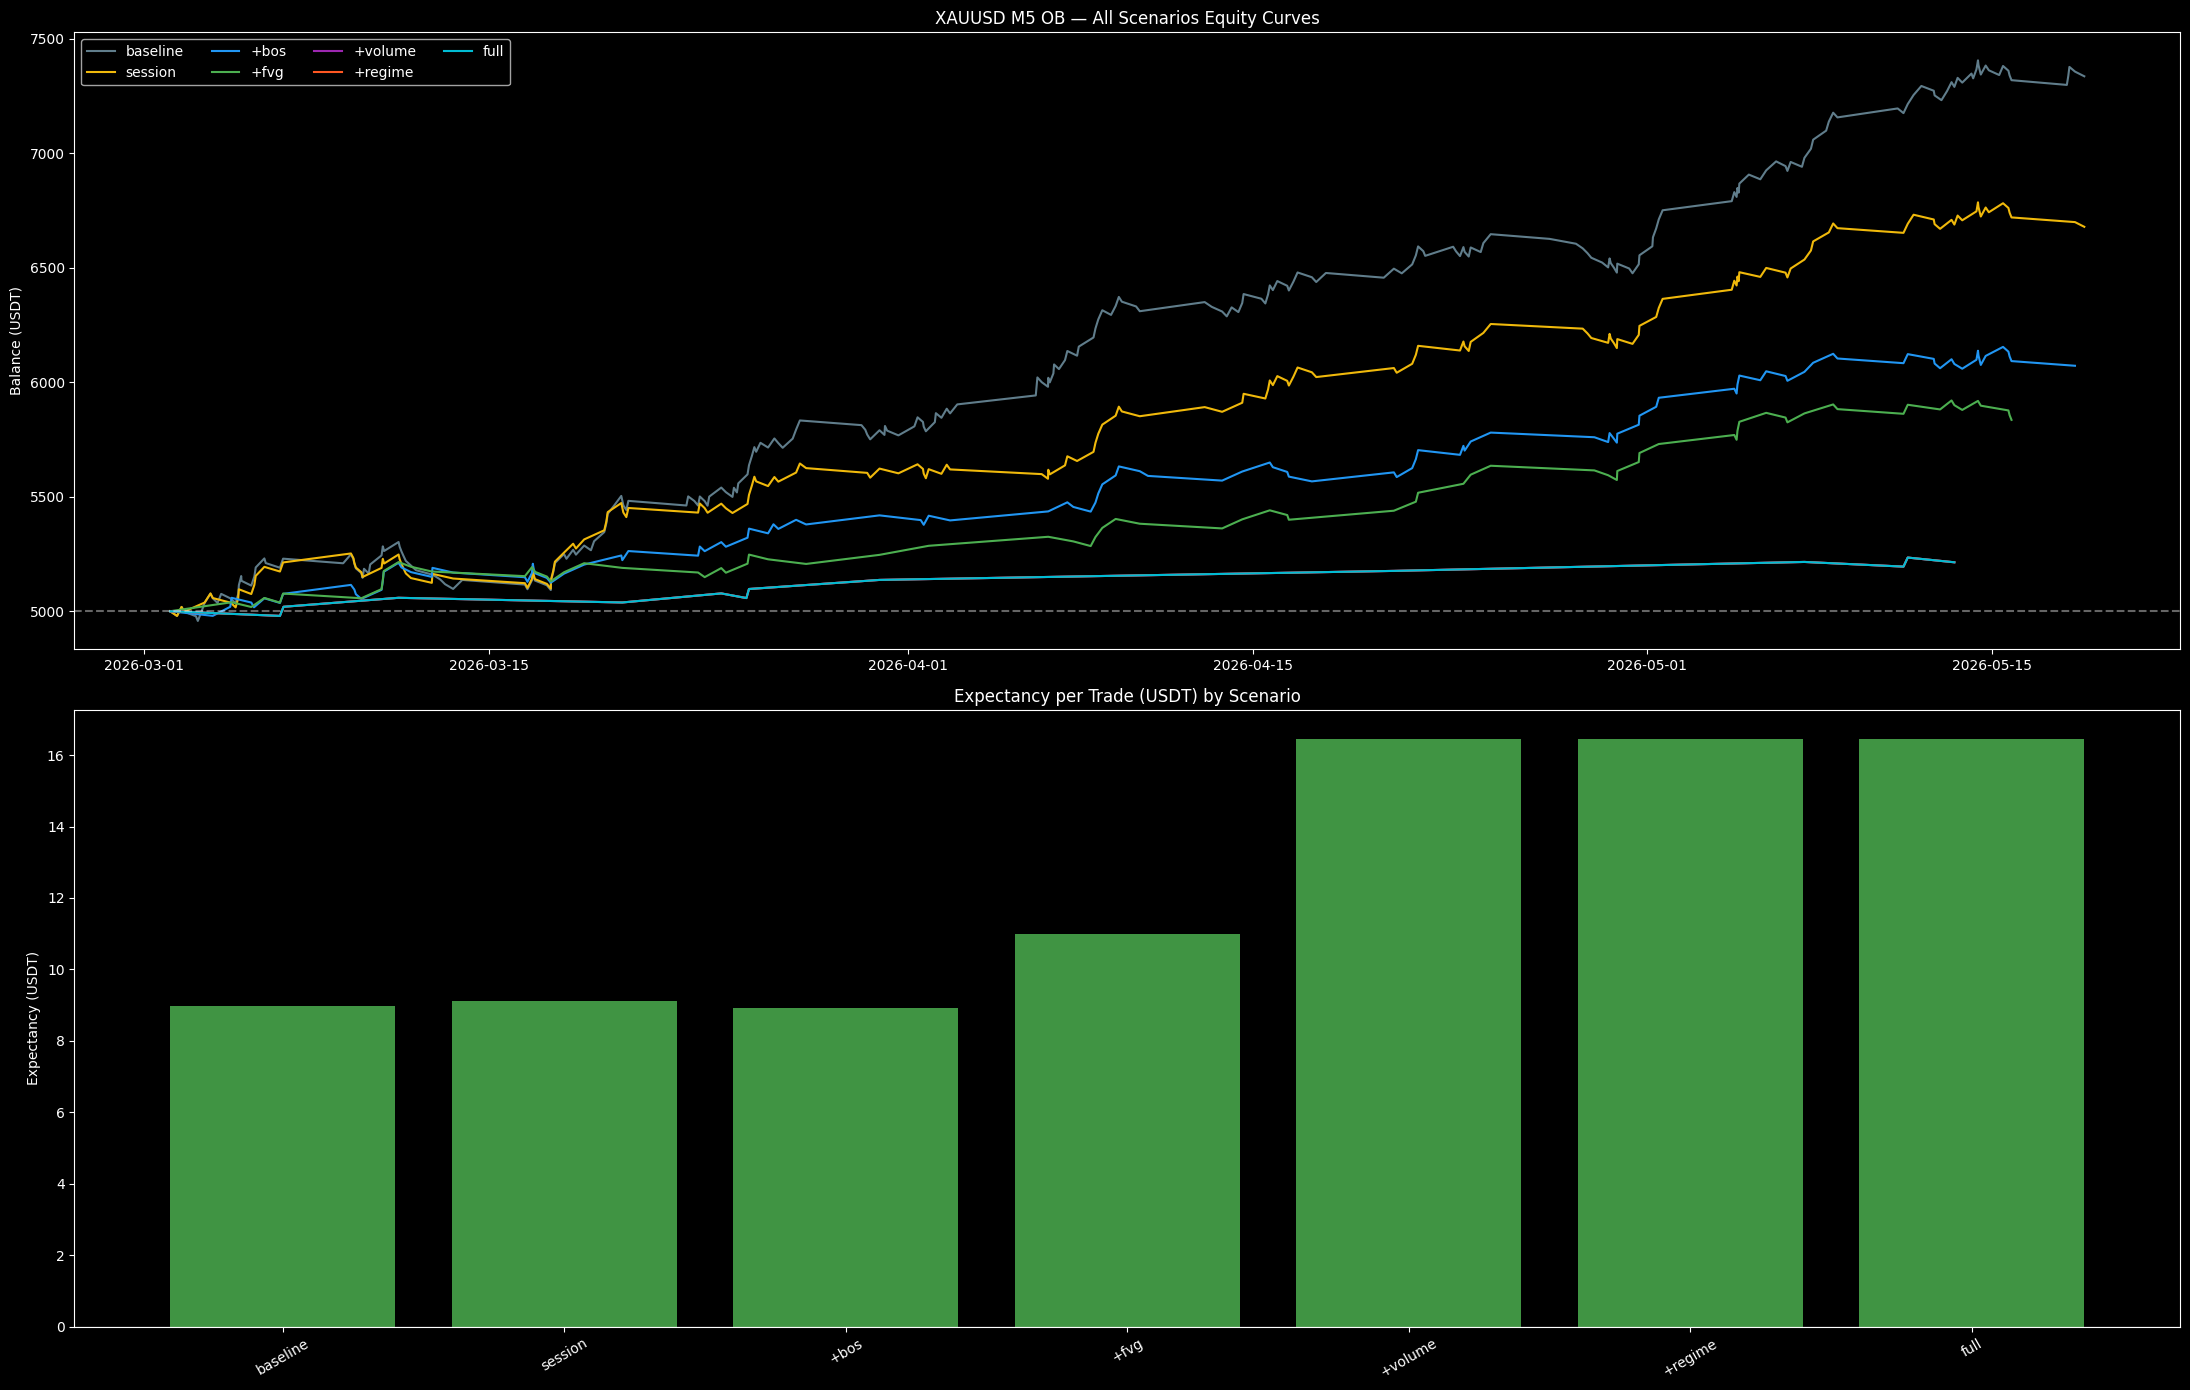


Best scenario: "+volume" with expectancy = $16.44 per trade
Use this scenario's OBSignalConfig in ob_trading_service.py


In [6]:
# ── Equity curve comparison ─────────────────────────────────────────────────
colors = ['#607D8B','#F0B90B','#2196F3','#4CAF50','#9C27B0','#FF5722','#00BCD4']

fig, axes = plt.subplots(2, 1, figsize=(22, 14))

# Equity curves
for (name, eq), color in zip(all_equities.items(), colors):
    label = name.split('_', 1)[-1]
    if not eq.empty:
        axes[0].plot(eq.index, eq.values, label=label, color=color, linewidth=1.5)

axes[0].axhline(START_BAL, color='white', linestyle='--', alpha=0.4)
axes[0].set_title(f'{SYMBOL} M5 OB — All Scenarios Equity Curves')
axes[0].set_ylabel('Balance (USDT)')
axes[0].legend(ncol=4, loc='upper left')

# Bar chart: expectancy by scenario
names  = [s.split('_', 1)[-1] for s in all_metrics]
expcts = [all_metrics[s]['expectancy'] or 0 for s in all_metrics]
bar_colors = ['#4CAF50' if e > 0 else '#F44336' for e in expcts]
axes[1].bar(names, expcts, color=bar_colors, alpha=0.85)
axes[1].axhline(0, color='white', linewidth=0.8)
axes[1].set_title('Expectancy per Trade (USDT) by Scenario')
axes[1].set_ylabel('Expectancy (USDT)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../notebooks_ob/results/12_equity_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# Final recommendation
best = max(all_metrics, key=lambda k: all_metrics[k]['expectancy'] or -999)
best_label = best.split('_', 1)[-1]
best_exp   = all_metrics[best]['expectancy']
print(f'\nBest scenario: "{best_label}" with expectancy = ${best_exp:.2f} per trade')
print('Use this scenario\'s OBSignalConfig in ob_trading_service.py')